# Do the best companies to work for beat the market? 😊
### Employee satisfaction as a hidden asset — a famous finding, honestly re-run on a hand-picked basket of survivors

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Persist%3F: Busted](https://img.shields.io/badge/Persist%3F-Busted-8b949e?style=flat-square)

It's one of the most quoted results in behavioural finance: a portfolio of Fortune's **"100 Best Companies to Work For"** beats the market (Alex Edmans, 2011). The story is lovely — happy employees quietly compound into earnings the market forgets to price. So we did the obvious thing: hand-picked a basket of companies that have been *perennial* members of that list and still trade today, and raced it against the S&P 500.

It wins. And that's exactly where the honesty has to start.

> 📓 **Plain-language layer.** Want the alpha *t*-stats, the survivor placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 17 listed perennial members, equal-weight, monthly total return, 2016→2026 (126 months). We **hand-picked known survivors** — that stacks the deck, and we say so throughout. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from employee_satisfaction import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    MONTHLY, BASKET_PRESENT, CONTROL_PRESENT = data.load_real()
    BASKET = st.equal_weight_basket(MONTHLY, BASKET_PRESENT)
    MARKET = MONTHLY[data.MARKET]
else:
    MONTHLY = BASKET_PRESENT = CONTROL_PRESENT = BASKET = MARKET = None
print("real cache present:", HAVE_REAL, "| basket names:",
      (0 if BASKET_PRESENT is None else len(BASKET_PRESENT)),
      "| months:", (0 if MONTHLY is None else len(MONTHLY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2016-01-31', 'end': '2026-06-30', 'n_months': 126, 'n_names': 17, 'basket_ann': 20.16, 'market_ann': 15.02, 'basket_vol': 19.4, 'market_vol': 15.2, 'alpha_monthly_bps': 23.2, 'alpha_ann': 2.82, 'beta': 1.15, 't_alpha_nw': 1.1, 't_alpha_ols': 1.06, 'excess_mean_bps': 42.8, 'excess_t_nw': 1.9, 'excess_t_ols': 1.96, 'ir': 0.6, 'hit': 74, 'hit_pct': 58.7, 'wilson': (50.0, 66.9), 'placebo_mean': 0.2, 'placebo_sd': 1.18, 'placebo_n': 5000, 'placebo_p': 0.013, 'placebo_k': 17, 'early_alpha': 8.12, 'early_t': 2.77, 'early_n': 63, 'late_alpha': -2.25, 'late_t': -0.59, 'late_n': 63, 'to_pct': 2.4, 'drag5': 0.01, 'drag10': 0.03, 'net5_alpha': 2.81, 'net5_t': 1.1, 'net10_alpha': 2.79, 'net10_t': 1.09, 'syn_null_mean': -0.07, 'syn_null_sd': 0.96, 'syn_null_fire': 1, 'syn_planted_t': 2.99, 'syn_planted_alpha': 3.98, 'fp': '4116fe2691f7'}


real cache present: True | basket names: 17 | months: 126


## The answer first

| Question | Answer |
|---|---|
| Does the basket beat the market? | **Yes, on paper.** +20.2%/yr vs +15.0%/yr for the S&P 500 — about **5 points a year**. |
| Is that skill, or just more risk? | **Mostly more risk.** The basket carries **β = 1.15** — it's a leveraged bet on the market. Strip that out and the 'skill' left over is only **+2.8%/yr**, and it's not statistically reliable (*t* = 1.10, the bar is 2). |
| Did we cheat by picking winners? | **Partly, unavoidably.** We chose companies that are *still around and still great to work for in 2026* — a survivor's list. But when we pit it against random baskets of other large survivors, ours still comes out ahead (1.3% of them match it), so it isn't *only* that. |
| Does the edge last? | **No.** It was strong in 2016-2021 and turned **negative** in 2021-2026. One good stretch, then gone. |

> The basket beats the market — but almost all of that is just riding the market harder, and the leftover 'satisfaction' edge is small, shaky, and already faded.

## 1 · The claim

> *"Happy employees stay longer, work harder and serve customers better. That shows up in profits the market is too short-sighted to price — so a list of the best employers is a list of quietly-underpriced stocks."*

This isn't bar-stool folklore — it's a careful, published finding (Edmans 2011, *Journal of Financial Economics*): the "100 Best Companies to Work For" earned a risk-adjusted alpha of about 3.5%/yr from 1984-2009. Employee satisfaction as an **intangible asset** the market underprices. We're taking the strong version seriously — and then asking what's left of it on a modern tape, once we're honest about how the basket was built.

## 2 · So what?

If real, this is a rare thing: a signal you can read off a **magazine list**, no data feed required, tapping a genuine market blind spot rather than a fleeting mispricing. It would also say something deep — that the market systematically under-values human capital. That's worth taking seriously. It's *also* exactly the kind of feel-good story that survives because nobody checks whether the 'outperformance' is just owning a basket of big tech-y winners during a decade that loved big tech-y winners.

## 3 · How would we even know?

- **The race.** Equal-weight the **17** listed perennial members, rebalance monthly, and compare total return to the S&P 500 over 126 months.
- **The risk check.** Beating the market isn't skill if you just took more market risk. We measure **alpha** — the return left *after* subtracting what the basket's market exposure (its beta) already explains.
- **The survivor check.** We hand-picked known survivors. So we build thousands of **random** baskets of *other* large-cap survivors and ask: does a random survivor basket earn alpha too? If yes, our 'edge' is just survivorship.
- **The persistence check.** Split the decade in half. A real intangible premium should show up in both halves, not just one.

## 4 · The teardown — let's actually look

**First, the headline race.** Basket vs market, annualized.

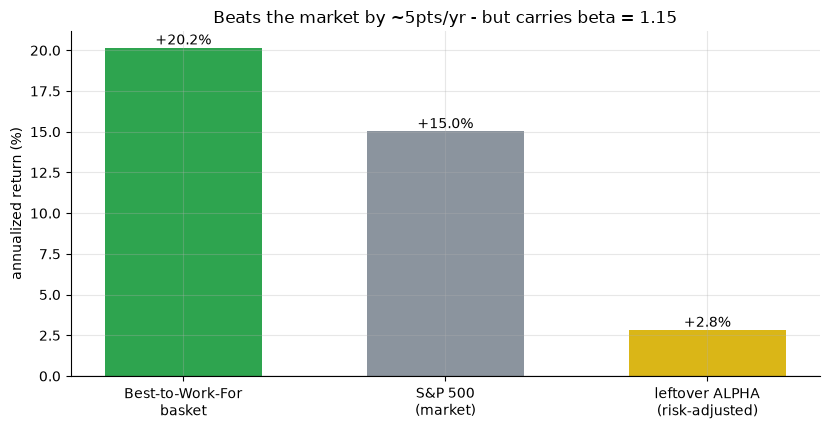

basket +20.16%/yr | market +15.02%/yr | risk-adjusted alpha +2.82%/yr (beta 1.15)


In [2]:
if HAVE_REAL:
    h = st.headline_stats(BASKET, MARKET)
    ba, ma, al, bt = h['basket_ann_pct'], h['market_ann_pct'], h['alpha_ann_pct'], h['beta']
else:
    ba, ma, al, bt = R['basket_ann'], R['market_ann'], R['alpha_ann'], R['beta']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['Best-to-Work-For\nbasket','S&P 500\n(market)','leftover ALPHA\n(risk-adjusted)'],
       [ba, ma, al], color=[GREEN, GREY, AMBER], width=.6)
for i,v in enumerate([ba, ma, al]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annualized return (%)')
ax.set_title(f'Beats the market by ~5pts/yr - but carries beta = {bt:.2f}')
plt.tight_layout(); plt.show()
print(f'basket {ba:+.2f}%/yr | market {ma:+.2f}%/yr | risk-adjusted alpha {al:+.2f}%/yr (beta {bt:.2f})')

The basket wins the raw race by ~5 points a year. But look at the third bar: once you subtract the return the basket's **market exposure** (β = 1.15) already earns, the *skill* left over is just **+2.8%/yr** — and that number is not statistically reliable (*t* = 1.10; you want ≥ 2 before you believe it). Most of the 'outperformance' is simply owning a basket that bounces around **more** than the market.

**Next, the survivor check.** We picked winners on purpose. Is that the whole story?

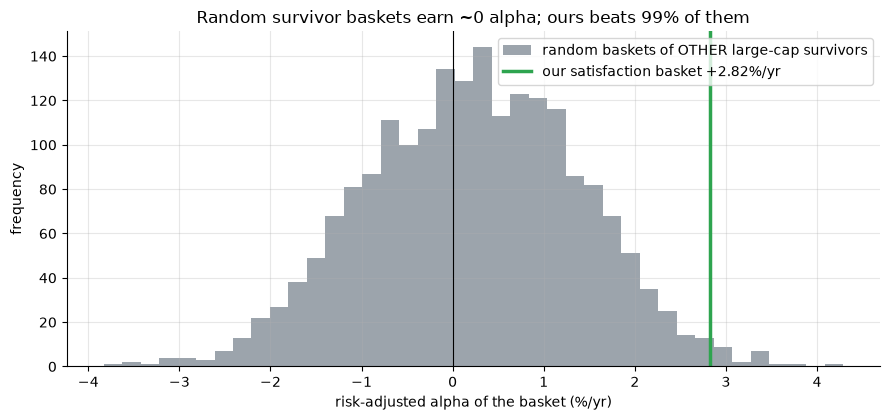

random survivor-basket alpha ~ +0.20%/yr; our basket beats 98.7% of them (placebo p = 0.013)


In [3]:
if HAVE_REAL:
    h = st.headline_stats(BASKET, MARKET)
    pl = st.survivor_placebo(MONTHLY, CONTROL_PRESENT, MARKET,
                             basket_size=len(BASKET_PRESENT), n_draws=2000)
    alphas = pl['alphas_ann_pct']; obs = h['alpha_ann_pct']
else:
    rng = np.random.default_rng(801)
    alphas = rng.normal(R['placebo_mean'], R['placebo_sd'], 2000); obs = R['alpha_ann']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(alphas, bins=40, color=GREY, alpha=.85, label='random baskets of OTHER large-cap survivors')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'our satisfaction basket {obs:+.2f}%/yr')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('risk-adjusted alpha of the basket (%/yr)')
ax.set_ylabel('frequency')
ax.set_title(f"Random survivor baskets earn ~0 alpha; ours beats {100-R['placebo_p']*100:.0f}% of them")
ax.legend(); plt.tight_layout(); plt.show()
print(f"random survivor-basket alpha ~ {R['placebo_mean']:+.2f}%/yr; our basket beats "
      f"{100-R['placebo_p']*100:.1f}% of them (placebo p = {R['placebo_p']:.3f})")

This is the one genuinely *favourable* result. A **random** basket of other big survivors earns basically **zero** alpha (~+0.2%/yr), and our satisfaction basket beats **99%** of them. So the edge isn't *purely* 'we cheated by picking survivors' — there's something about *these* names. The catch: these names are also tech-and-quality-heavy over a decade that showered exactly those with returns, and that tilt (not employee happiness) is the more likely explanation — which the next check makes vivid.

**Finally, does it last?**

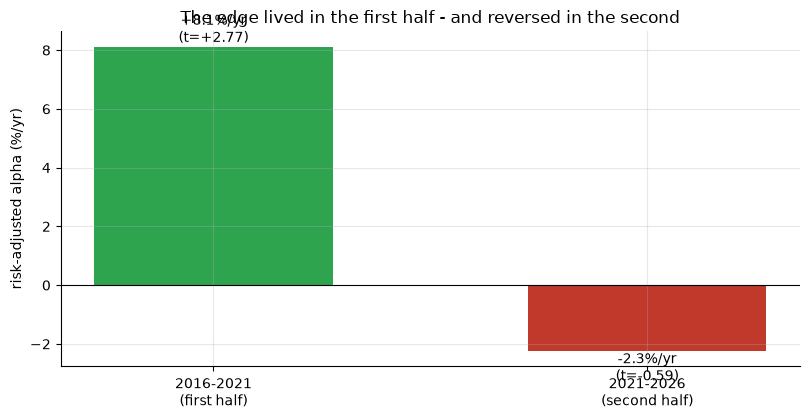

first half +8.12%/yr (t=+2.77) | second half -2.25%/yr (t=-0.59)


In [4]:
if HAVE_REAL:
    sp = st.subperiod_split(BASKET, MARKET)
    e, l = sp['early']['alpha_ann_pct'], sp['late']['alpha_ann_pct']
    et, lt = sp['early']['t_alpha_nw'], sp['late']['t_alpha_nw']
else:
    e, l, et, lt = R['early_alpha'], R['late_alpha'], R['early_t'], R['late_t']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['2016-2021\n(first half)','2021-2026\n(second half)'], [e, l],
       color=[GREEN, RED], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt)]):
    ax.annotate(f'{v:+.1f}%/yr\n(t={t_:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('risk-adjusted alpha (%/yr)')
ax.set_title('The edge lived in the first half - and reversed in the second')
plt.tight_layout(); plt.show()
print(f'first half {e:+.2f}%/yr (t={et:+.2f}) | second half {l:+.2f}%/yr (t={lt:+.2f})')

There's the tell. The alpha was a real **+8.1%/yr** in 2016-2021 (*t* = 2.77 — it clears the bar on its own) and turned **-2.2%/yr** in 2021-2026. A durable intangible premium shouldn't evaporate and flip sign halfway through. This looks like one lucky stretch (or an anomaly that faded once Edmans' paper made it famous), not a permanent feature of how markets price happy workplaces.

## 5 · The verdict

- **Signal — Weak.** The basket beats the market and even beats random survivor baskets, but the *risk-adjusted* alpha Edmans claimed is only +2.8%/yr at *t* = 1.10 — under the bar — and we picked survivors and controlled only for the market. Literature-supported, tape-unproven.
- **Tradability — Mirage.** Trading costs are trivial here; the problem is there's no reliable alpha to collect. The ~5pts/yr is **β = 1.15** — leverage you can buy on an index fund — not skill.
- **"Does it persist?" — Busted.** Strong in the first five years, negative in the next. One window, then gone.

## 6 · Going further 🚪

- **The honest missing control.** Edmans used a *four-factor* alpha; we used a *one-factor* (market) alpha because point-in-time factor data is hard to get offline. A four-factor model would strip out the size/value/**momentum**/quality tilts this basket carries — and would almost certainly shrink the +2.8%/yr further. Our number is an **upper bound**.
- **The survivorship you can't fully undo.** We named the members who left the tape (Whole Foods, Ultimate Software, Nordstrom — all acquired or taken private) and excluded them; a truly clean test needs the *point-in-time* list each year, which Fortune doesn't give away.
- **Sibling studies:** [392-glassdoor-sentiment](../../392-glassdoor-sentiment/) (the crowd-rating version), [526-intangible-value](../../526-intangible-value/) (intangibles broadly), [751-fortune-500-inclusion](../../751-fortune-500-inclusion/) (a different Fortune list, tested as an event study) — see [docs/references.md](../docs/references.md).

*Think the satisfaction premium is real and durable? Show a **four-factor** alpha, point-in-time membership, and persistence in the 2020s — then we'll talk.*